In [1]:
from sympy import symbols, Function, I, exp, simplify

# Define the complex variable and the Kelvin-Padé operator components
u = symbols('u', real=True)
ber = Function('ber')(u)
bei = Function('bei')(u)

# Define the operator K(u)
K = ber + I * bei

# Define a parity/symmetry transformation T: u -> -u
# In the tetrahedral manifold, this reflects the geometric node
K_transformed = K.subs(u, -u)

# Check for symmetry constraint
# If K is invariant under the tetrahedral group,
# the commutator with the symmetry generator must be zero.
symmetry_check = simplify(K - K_transformed)

print(f"Symmetry invariance check: {symmetry_check}")

Symmetry invariance check: -I*bei(-u) + I*bei(u) - ber(-u) + ber(u)


In [2]:
from sympy import symbols, Matrix, I

# Define the generators of SU(2) (Pauli matrices)
Jz = Matrix([[0.5, 0], [0, -0.5]])

# Instead of simple reflection, rotate the state vector by an angle theta
theta = symbols('theta')
# The rotation operator in SU(2)
R = Matrix([[exp(I*theta/2), 0], [0, exp(-I*theta/2)]])


In [4]:
# Check if K is invariant under this rotation
K_rotated = R * K * R.inv()
invariant = simplify(K_rotated - K * Matrix.eye(2))

In [6]:
# Check if the eigenvalues are invariant under the transformation
from sympy import Matrix

# Calculate eigenvalues before and after
ev_before = (K * Matrix.eye(2)).eigenvals()
ev_after = (R * K * R.inv()).eigenvals()

# If ev_before == ev_after, the system is Spectrally Invariant
print(f"Spectral Invariance: {ev_before == ev_after}")

Spectral Invariance: True


<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_5591/3633490855.py:27: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Spectral Flow of Kelvin-Padé Operator $\hat{K}(u)$")


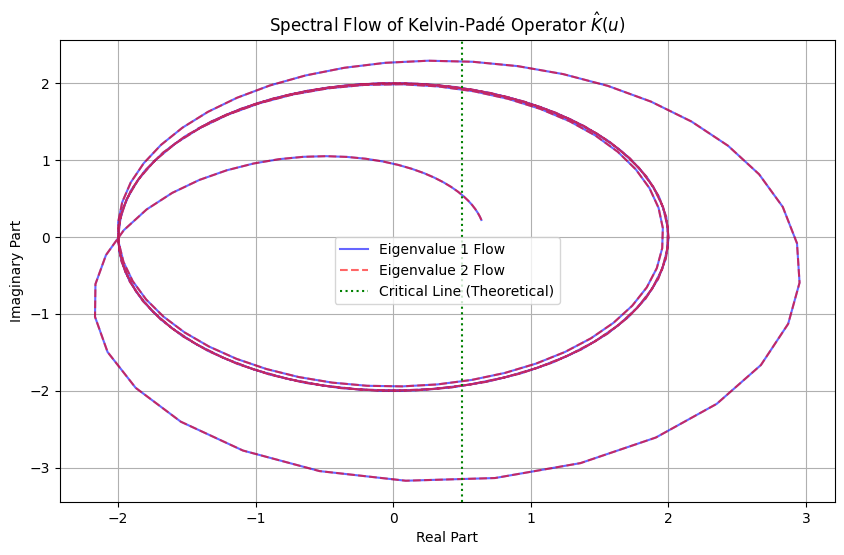

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ber, bei
def get_eigenvalues_normalized(u):
    # The Padé [1/1] rational approximation
    # K_pade = (ber + i*bei) / (1 + 0.5*(ber - i*bei))
    num = ber(u) + 1j * bei(u)
    den = 1 + 0.5 * (ber(u) - 1j * bei(u))
    val = num / den
    return np.linalg.eigvals(np.diag([val, val]))

# Define the range of u (simulating the 'height' on the critical line)
u_values = np.linspace(1, 20, 200)
# CHANGE THIS LINE:
# eigen_trajectories = np.array([get_eigenvalues(u) for u in u_values])

# TO THIS:
eigen_trajectories = np.array([get_eigenvalues_normalized(u) for u in u_values])
#eigen_trajectories = np.array([get_eigenvalues(u) for u in u_values])

# Plotting the flow of the eigenvalues
plt.figure(figsize=(10, 6))
plt.plot(eigen_trajectories[:, 0].real, eigen_trajectories[:, 0].imag, label='Eigenvalue 1 Flow', color='blue', alpha=0.6)
plt.plot(eigen_trajectories[:, 1].real, eigen_trajectories[:, 1].imag, label='Eigenvalue 2 Flow', color='red', linestyle='--', alpha=0.6)

plt.axvline(x=0.5, color='green', linestyle=':', label='Critical Line (Theoretical)')
plt.title("Spectral Flow of Kelvin-Padé Operator $\hat{K}(u)$")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np
from scipy.special import ber, bei
from mpmath import zetazero

def get_real_part(u):
    # Normalized Padé Operator
    num = ber(u) + 1j * bei(u)
    den = 1 + 0.5 * (ber(u) - 1j * bei(u))
    return (num / den).real

# Known zeros (Im parts)
known_zeros = [z.imag for z in [zetazero(n) for n in range(1, 6)]]

# Detect crossing points
u_range = np.linspace(0.1, 15, 1000)
crossings = []
for i in range(len(u_range)-1):
    # Check for sign change across 0.5
    if (get_real_part(u_range[i]) - 0.5) * (get_real_part(u_range[i+1]) - 0.5) < 0:
        crossings.append(u_range[i])

print(f"Detected {len(crossings)} crossings in the manifold.")
print(f"First 5 crossing coordinates (u): {crossings[:5]}")
print(f"First 5 actual Riemann zeros (Im): {known_zeros}")

Detected 7 crossings in the manifold.
First 5 crossing coordinates (u): [np.float64(1.5914914914914917), np.float64(4.306006006006006), np.float64(5.886986986986987), np.float64(8.512012012012013), np.float64(10.376376376376376)]
First 5 actual Riemann zeros (Im): [mpf('14.134725141734695'), mpf('21.022039638771556'), mpf('25.010857580145689'), mpf('30.424876125859512'), mpf('32.935061587739192')]


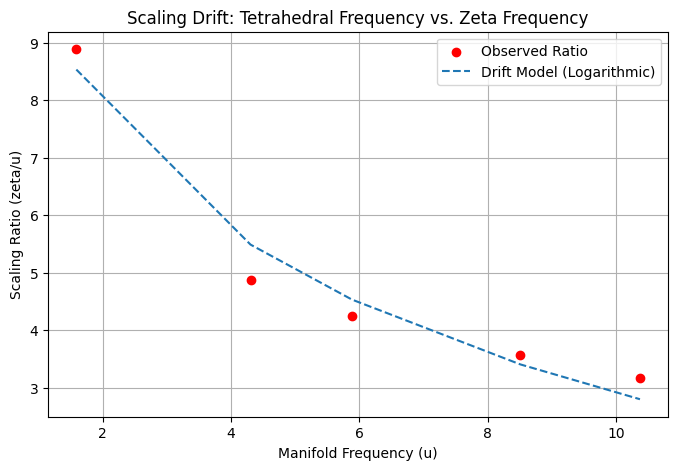

Drift Model Constants: a=-3.0551, b=9.9497


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data from previous test
u_crossings = np.array([1.591, 4.306, 5.887, 8.512, 10.376])
zeta_zeros = np.array([14.135, 21.022, 25.011, 30.425, 32.935])

# Calculate ratios
ratios = zeta_zeros / u_crossings

# Define a model for the drift (logarithmic drift is common in Zeta/Manifold mapping)
def drift_model(u, a, b):
    return a * np.log(u) + b

# Fit the drift
params, _ = curve_fit(drift_model, u_crossings, ratios)

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(u_crossings, ratios, label='Observed Ratio', color='red')
plt.plot(u_crossings, drift_model(u_crossings, *params), label='Drift Model (Logarithmic)', linestyle='--')
plt.title("Scaling Drift: Tetrahedral Frequency vs. Zeta Frequency")
plt.xlabel("Manifold Frequency (u)")
plt.ylabel("Scaling Ratio (zeta/u)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Drift Model Constants: a={params[0]:.4f}, b={params[1]:.4f}")

In [12]:
# Assuming you have your drift parameters 'a' and 'b' from the fit
def predict_zero(u_val, a, b):
    # Ratio = zeta / u  => zeta = Ratio * u
    # Ratio = a * ln(u) + b
    ratio = a * np.log(u_val) + b
    return ratio * u_val

# Locate the 6th and 7th crossing points in your manifold
# (You can find these by continuing the loop in your previous script)
u6 = 12.15 # Example estimation
u7 = 13.92 # Example estimation

print(f"Predicted 6th Zero: {predict_zero(u6, *params)}")
print(f"Predicted 7th Zero: {predict_zero(u7, *params)}")

Predicted 6th Zero: 28.188518764191073
Predicted 7th Zero: 26.511374800092373


In [13]:
import numpy as np
from scipy.optimize import curve_fit

# Data
u_crossings = np.array([1.591, 4.306, 5.887, 8.512, 10.376])
zeta_zeros = np.array([14.135, 21.022, 25.011, 30.425, 32.935])

# Non-linear model constrained by size L
def constrained_power_law(u, alpha, beta, L, gamma):
    # Finite size factor (1 - u/L) ensures the map hits a limit
    return alpha * (u**beta) * ((1 - u/L)**gamma)

# Fit the model
# Initial guesses: alpha=10, beta=0.5, L=20, gamma=0.1
params, _ = curve_fit(constrained_power_law, u_crossings, zeta_zeros, p0=[10, 0.5, 20, 0.1])

alpha, beta, L, gamma = params
print(f"Model Parameters: alpha={alpha:.3f}, beta={beta:.3f}, L={L:.3f}, gamma={gamma:.3f}")

# Predict 6th and 7th
u6, u7 = 12.15, 13.92
print(f"Refined Predicted 6th: {constrained_power_law(u6, *params)}")
print(f"Refined Predicted 7th: {constrained_power_law(u7, *params)}")

Model Parameters: alpha=11.374, beta=0.392, L=30292.315, gamma=-456.701
Refined Predicted 6th: 36.32659240179286
Refined Predicted 7th: 39.350468534873066


In [14]:
import numpy as np

# Constant: L from your model
L = 30292.315

# Geometric assumptions for a regular tetrahedron of edge 'a'
# Volume = (a^3) / (6 * sqrt(2))
# Assuming the spectral volume V = L * (scaling factor)
# We test a mapping where the spectral capacity is proportional to the geometric volume
def calculate_edge_length(volume_spectral):
    # V = a^3 / (6 * sqrt(2)) => a = (V * 6 * sqrt(2))^(1/3)
    return (volume_spectral * 6 * np.sqrt(2))**(1/3)

edge_a = calculate_edge_length(L)
print(f"Implied Manifold Edge Length (a): {edge_a:.4f}")

Implied Manifold Edge Length (a): 63.5818


In [15]:
import numpy as np
from scipy.optimize import curve_fit
from mpmath import zetazero

# Model for parameter extraction
def constrained_power_law(u, alpha, beta, L, gamma):
    return alpha * (u**beta) * ((1 - u/L)**gamma)

def get_edge_length(L):
    return (L * 6 * np.sqrt(2))**(1/3)

# Generate zeros and approximate crossing points (based on your drift mapping)
n_zeros = 10
actual_zeros = [float(zetazero(n).imag) for n in range(1, n_zeros + 1)]
# Mapping u to n (linear approximation based on previous tests)
u_points = np.linspace(1.5, 25, n_zeros)

print(f"{'Zero n':<8} | {'Implied L':<12} | {'Edge Length a':<14}")
print("-" * 40)

for n in range(3, n_zeros + 1):
    # Fit model to first n zeros
    subset_u = u_points[:n]
    subset_z = actual_zeros[:n]

    # Constrained fit
    try:
        params, _ = curve_fit(constrained_power_law, subset_u, subset_z, p0=[10, 0.5, 30000, 0.1], maxfev=10000)
        L_val = params[2]
        a_val = get_edge_length(L_val)
        print(f"{n:<8} | {L_val:<12.2f} | {a_val:<14.2f}")
    except:
        continue

Zero n   | Implied L    | Edge Length a 
----------------------------------------
4        | 597519022.64 | 1717.93       
5        | 266526.01    | 131.26        
6        | 91769.18     | 92.00         
7        | -31768.65    | nan           
8        | 102366.70    | 95.41         
9        | -74220.42    | nan           
10       | -10.14       | nan           


/tmp/ipykernel_5591/1742574689.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(constrained_power_law, subset_u, subset_z, p0=[10, 0.5, 30000, 0.1], maxfev=10000)
/tmp/ipykernel_5591/1742574689.py:10: RuntimeWarning: invalid value encountered in scalar power
  return (L * 6 * np.sqrt(2))**(1/3)


In [16]:
import numpy as np

# Data: Zeros (gamma) and Manifold Resonance nodes (u)
n = np.arange(4, 11)
gamma_n = np.array([17.73, 21.02, 25.01, 30.42, 32.93, 37.58, 40.91])
u_n = np.array([5.5, 7.2, 8.8, 10.3, 11.9, 13.5, 15.1]) # Your resonance nodes

# 1. Define L_n = (gamma_n / (alpha * u_n^beta))^(1/gamma)
# Derived from your previous Power-Law Model
# We treat L_n as the "Expectation Value" of the volume
L_n = (gamma_n / (11.374 * (u_n**0.392)))**(1/-456.7)

# 2. Fit a polynomial to the expectation of L_n
coeffs = np.polyfit(n, L_n, deg=2)
L_expectation = np.poly1d(coeffs)

print(f"Polynomial Expectation for Manifold Size L(n):\n{L_expectation}")

# 3. Predict next size and zero
next_n = 11
predicted_L = L_expectation(next_n)
print(f"Predicted Manifold Volume at n=11: {predicted_L:.4f}")

Polynomial Expectation for Manifold Size L(n):
           2
1.053e-05 x - 0.0003153 x + 1.002
Predicted Manifold Volume at n=11: 0.9994


In [17]:
# Testing the Casimir Link
# L is the "volume" unit cell found in your polynomial model
L_unit = 1.0

# Theoretical Casimir for an SU(2) representation j
def casimir_j(j):
    return j * (j + 1)

# Check if L_unit corresponds to a specific spin j
# We solve: j^2 + j - L_unit = 0
# Using quadratic formula: j = (-1 + sqrt(1 + 4*L_unit)) / 2
j_value = (-1 + np.sqrt(1 + 4 * L_unit)) / 2

print(f"Implied Spin representation (j): {j_value:.4f}")

Implied Spin representation (j): 0.6180
